In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

data = pd.read_csv('Chocolate-Sales.csv')
data

,Sales Person,Country,Product,Date,Amount,Boxes Shipped
0,Jehu Rudeforth,UK,Mint Chip Choco,04-Jan-22,"$5,320",180
1,Van Tuxwell,India,85% Dark Bars,01-Aug-22,"$7,896",94
2,Gigi Bohling,India,Peanut Butter Cubes,07-Jul-22,"$4,501",91
3,Jan Morforth,Australia,Peanut Butter Cubes,27-Apr-22,"$12,726",342
4,Jehu Rudeforth,UK,Peanut Butter Cubes,24-Feb-22,"$13,685",184
...,...,...,...,...,...,...
1089,Karlen McCaffrey,Australia,Spicy Special Slims,17-May-22,"$4,410",323
1090,Jehu Rudeforth,USA,White Choc,07-Jun-22,"$6,559",119
1091,Ches Bonnell,Canada,Organic Choco Syrup,26-Jul-22,$574,217
1092,Dotty Strutley,India,Eclairs,28-Jul-22,"$2,086",384


In [2]:
# renomabrando los encabezados 
data = data.rename(columns={
    "Sales Person" : "Vendedor",
    "Country" : "Pais",
    "Product" : "Productos",
    "Date" : "Fecha",
    "Amount" : "Monto",
    "Boxes Shipped" : "Cajas_enviadas"
})
data.head()

,Vendedor,Pais,Productos,Fecha,Monto,Cajas_enviadas
0,Jehu Rudeforth,UK,Mint Chip Choco,04-Jan-22,"$5,320",180
1,Van Tuxwell,India,85% Dark Bars,01-Aug-22,"$7,896",94
2,Gigi Bohling,India,Peanut Butter Cubes,07-Jul-22,"$4,501",91
3,Jan Morforth,Australia,Peanut Butter Cubes,27-Apr-22,"$12,726",342
4,Jehu Rudeforth,UK,Peanut Butter Cubes,24-Feb-22,"$13,685",184


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1094 entries, 0 to 1093
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Vendedor        1094 non-null   object
 1   Pais            1094 non-null   object
 2   Productos       1094 non-null   object
 3   Fecha           1094 non-null   object
 4   Monto           1094 non-null   object
 5   Cajas_enviadas  1094 non-null   int64 
dtypes: int64(1), object(5)
memory usage: 51.4+ KB


In [4]:
print(data['Monto'].dtype)
print(data['Monto'].head())

object
0     $5,320 
1     $7,896 
2     $4,501 
3    $12,726 
4    $13,685 
Name: Monto, dtype: object


In [5]:
# quitamos el $ del monto
data['Monto'] = (data['Monto'].astype(str).str.replace('$', '', regex=False).str.replace(',', '', regex=False).str.strip().astype(float))
data['Fecha'] = pd.to_datetime(data['Fecha'], format='%d-%b-%y')

In [6]:
data

,Vendedor,Pais,Productos,Fecha,Monto,Cajas_enviadas
0,Jehu Rudeforth,UK,Mint Chip Choco,2022-01-04,5320.0,180
1,Van Tuxwell,India,85% Dark Bars,2022-08-01,7896.0,94
2,Gigi Bohling,India,Peanut Butter Cubes,2022-07-07,4501.0,91
3,Jan Morforth,Australia,Peanut Butter Cubes,2022-04-27,12726.0,342
4,Jehu Rudeforth,UK,Peanut Butter Cubes,2022-02-24,13685.0,184
...,...,...,...,...,...,...
1089,Karlen McCaffrey,Australia,Spicy Special Slims,2022-05-17,4410.0,323
1090,Jehu Rudeforth,USA,White Choc,2022-06-07,6559.0,119
1091,Ches Bonnell,Canada,Organic Choco Syrup,2022-07-26,574.0,217
1092,Dotty Strutley,India,Eclairs,2022-07-28,2086.0,384


In [7]:
print(data.isnull().sum()) # datos faltantes
print("-------------------")
print(data.duplicated().sum()) # valores faltantes

Vendedor          0
Pais              0
Productos         0
Fecha             0
Monto             0
Cajas_enviadas    0
dtype: int64
-------------------
0


In [8]:
print(data["Vendedor"].unique())
print("---------------------------------------------------------------")
print(data["Productos"].unique())
print("---------------------------------------------------------------")
print(data["Pais"].unique())

['Jehu Rudeforth' 'Van Tuxwell' 'Gigi Bohling' 'Jan Morforth' 'Oby Sorrel'
 'Gunar Cockshoot' 'Brien Boise' 'Rafaelita Blaksland' 'Barr Faughny'
 'Mallorie Waber' 'Karlen McCaffrey' "Marney O'Breen" 'Beverie Moffet'
 'Roddy Speechley' 'Curtice Advani' 'Husein Augar' 'Kaine Padly'
 'Dennison Crosswaite' "Wilone O'Kielt" 'Andria Kimpton' 'Kelci Walkden'
 'Camilla Castle' 'Madelene Upcott' 'Dotty Strutley' 'Ches Bonnell']
---------------------------------------------------------------
['Mint Chip Choco' '85% Dark Bars' 'Peanut Butter Cubes'
 'Smooth Sliky Salty' '99% Dark & Pure' 'After Nines' '50% Dark Bites'
 'Orange Choco' 'Eclairs' 'Drinking Coco' 'Organic Choco Syrup'
 'Milk Bars' 'Spicy Special Slims' 'Fruit & Nut Bars' 'White Choc'
 'Manuka Honey Choco' 'Almond Choco' 'Raspberry Choco'
 'Choco Coated Almonds' "Baker's Choco Chips" 'Caramel Stuffed Bars'
 '70% Dark Bites']
---------------------------------------------------------------
['UK' 'India' 'Australia' 'New Zealand' 'USA' '

In [9]:
# cantidad de veces que se repite cada producto
data["Productos"].value_counts()

Productos
Eclairs                 60
50% Dark Bites          60
Smooth Sliky Salty      59
White Choc              58
Drinking Coco           56
Spicy Special Slims     54
Organic Choco Syrup     52
85% Dark Bars           50
Fruit & Nut Bars        50
After Nines             50
Peanut Butter Cubes     49
99% Dark & Pure         49
Milk Bars               49
Raspberry Choco         48
Almond Choco            48
Orange Choco            47
Mint Chip Choco         45
Manuka Honey Choco      45
Caramel Stuffed Bars    43
70% Dark Bites          42
Baker's Choco Chips     41
Choco Coated Almonds    39
Name: count, dtype: int64

In [10]:
# ¿donde se vende mas?
ventas_por_pais = data.groupby("Pais")["Monto"].sum().sort_values(ascending=False)
ventas_por_pais

Pais
Australia      1137367.0
UK             1051792.0
India          1045800.0
USA            1035349.0
Canada          962899.0
New Zealand     950418.0
Name: Monto, dtype: float64

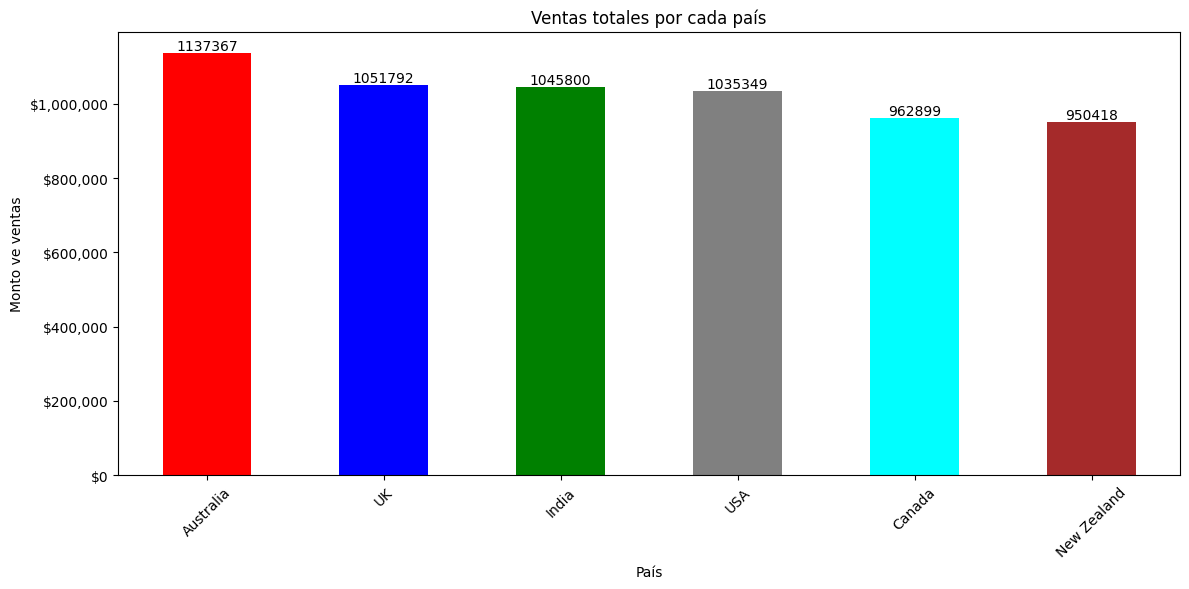

In [11]:
from matplotlib.ticker import FuncFormatter
ax = ventas_por_pais.plot(kind="bar", figsize=(12, 6), color=["red", "blue", "green", "gray", "cyan", "brown"])

plt.title("Ventas totales por cada país")
plt.ylabel("Monto ve ventas")
plt.xlabel("País")
plt.xticks(rotation=45)

#cambio los valores del eje y
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'${x:,.0f}'))

# colocamos los valores a cada barra 
for i, valor in enumerate(ventas_por_pais):
    ax.text(i, valor, f"{valor:.0f}", ha="center", va="bottom")

plt.tight_layout()
plt.show()

In [12]:
# productos que mas se venden
ventas_por_producto = data.groupby("Productos")["Monto"].sum().sort_values(ascending=False).head(6)
ventas_por_producto

Productos
Smooth Sliky Salty     349692.0
50% Dark Bites         341712.0
White Choc             329147.0
Peanut Butter Cubes    324842.0
Eclairs                312445.0
99% Dark & Pure        299796.0
Name: Monto, dtype: float64

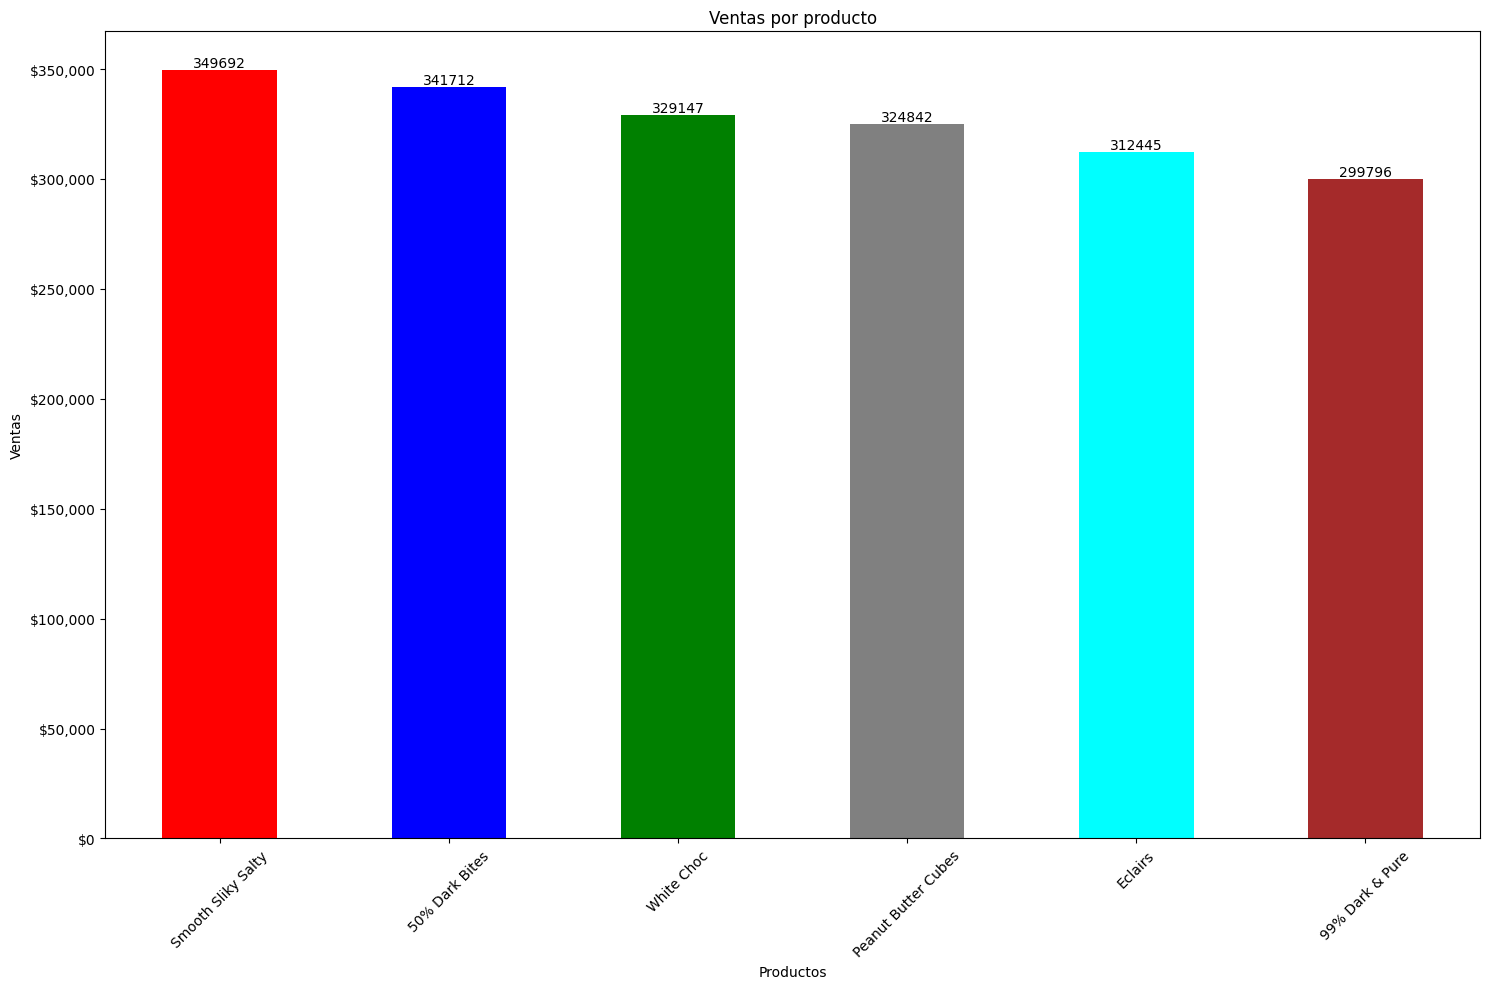

In [13]:
ax = ventas_por_producto.plot(kind="bar", figsize=(15, 10), color=["red", "blue", "green", "gray", "cyan", "brown"])

plt.title("Ventas por producto")
plt.xlabel("Productos")
plt.ylabel("Ventas")
plt.xticks(rotation=45)

# cambiamos los valores del eje y
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'${x:,.0f}'))

# colocamos los valores a cada barra 
for i, valor in enumerate(ventas_por_producto):
    ax.text(i, valor, f"{valor:.0f}", ha="center", va="bottom")

plt.tight_layout()
plt.show()

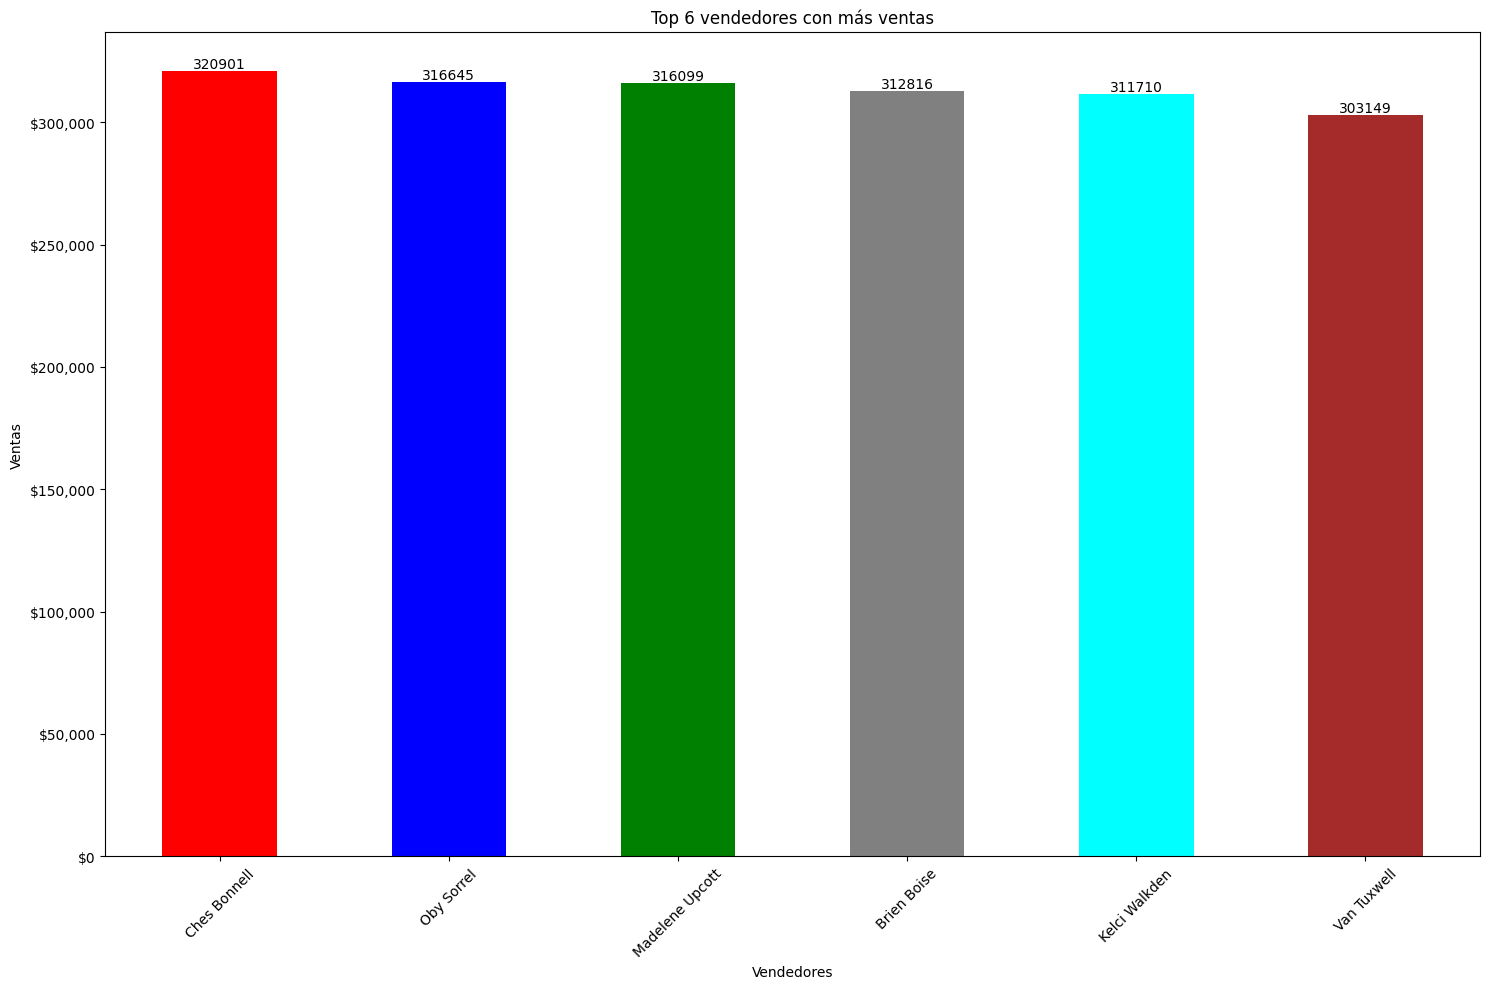

In [16]:
ventas_por_vendedor = data.groupby("Vendedor")["Monto"].sum().sort_values(ascending=False).head(6)
ax = ventas_por_vendedor.plot(kind="bar", figsize=(15, 10), color=["red", "blue", "green", "gray", "cyan", "brown"])

plt.title("Top 6 vendedores con más ventas")
plt.xlabel("Vendedores")
plt.ylabel("Ventas")
plt.xticks(rotation=45)

# cambiamos a formato de moneda los valores del eje y
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'${x:,.0f}'))

# colocamos los valores a cada barra
for i, valor in enumerate(ventas_por_vendedor):
    ax.text(i, valor, f"{valor:.0f}", ha="center", va="bottom")

plt.tight_layout()
plt.show()

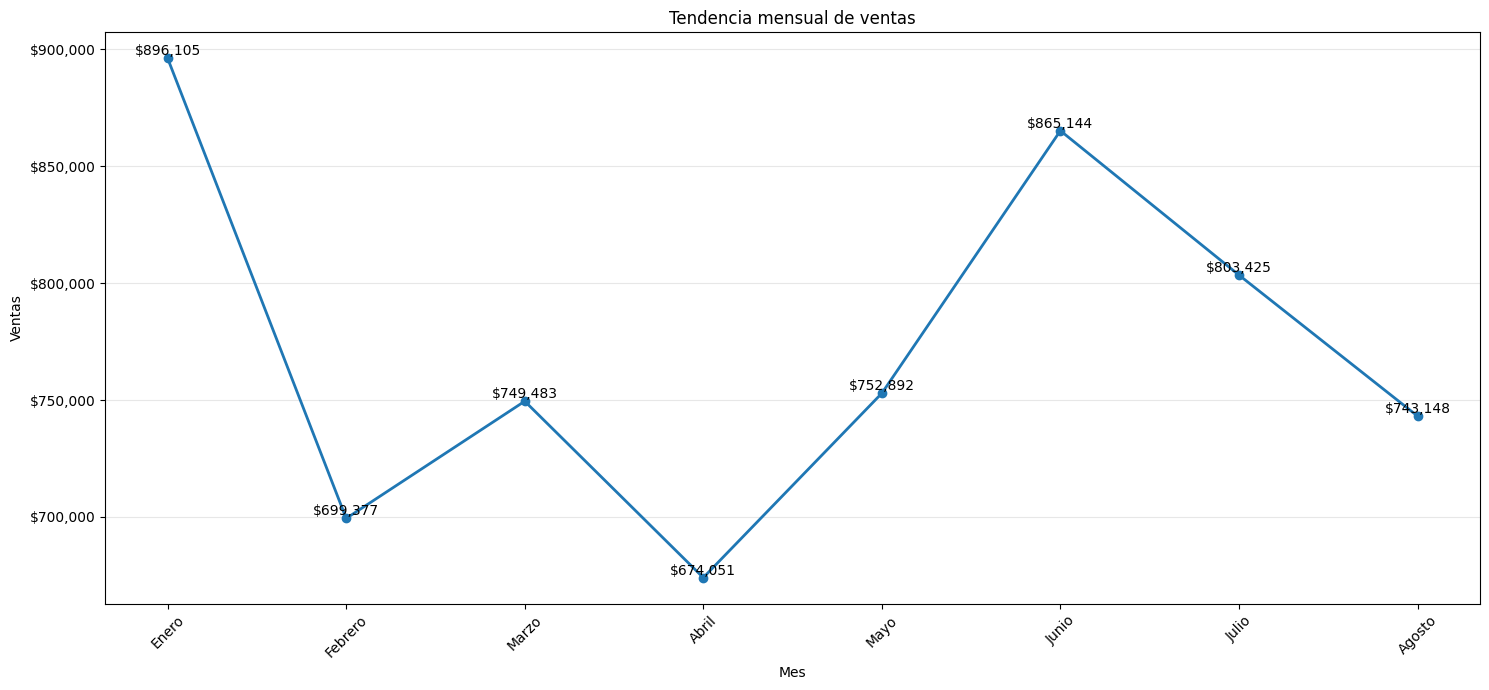

In [ ]:
# ventas agrupadas por mes
ventas_por_mes = (data.groupby(data["Fecha"].dt.month)["Monto"].sum().sort_index())

# nombres de los meses
meses = ["Enero", "Febrero", "Marzo", "Abril", "Mayo", "Junio", "Julio", "Agosto","Septiembre", "Octubre", "Noviembre", "Diciembre"]

# cambiamos números por nombres
ventas_por_mes.index = [meses[i-1] for i in ventas_por_mes.index]

fig, ax = plt.subplots(figsize=(15, 7))

ax.plot(ventas_por_mes.index, ventas_por_mes.values, marker="o", linewidth=2)

plt.title("Tendencia mensual de ventas")
plt.xlabel("Mes")
plt.ylabel("Ventas")
plt.xticks(rotation=45)

# formato del eje Y
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'${x:,.0f}'))

# numero encima de cada punto
for i, valor in enumerate(ventas_por_mes.values):
    ax.text(i, valor, f"${valor:,.0f}", ha="center", va="bottom", fontsize=10)

plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

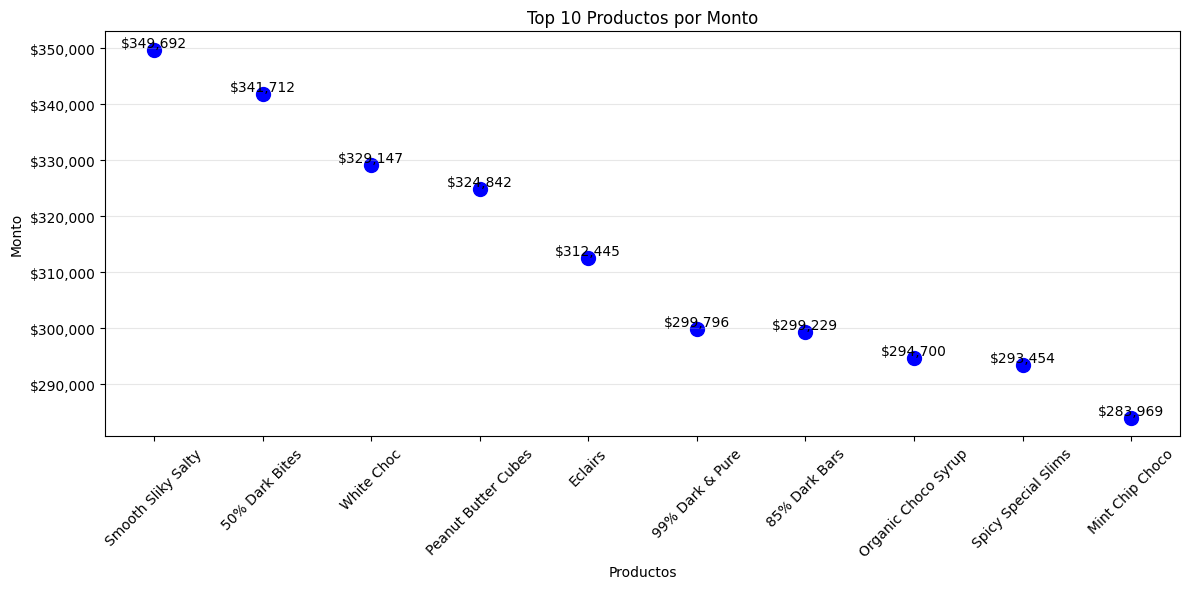

In [30]:
# Monto generado por cada producto
precio_producto = data.groupby("Productos")["Monto"].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(12, 6))
plt.scatter(precio_producto.index, precio_producto.values, color="blue", s=100)
plt.xlabel("Productos")
plt.ylabel("Monto")
plt.title("Top 10 Productos por Monto")
plt.xticks(rotation=45)
plt.tight_layout()

# damos formato de dinero a los valores del eje y
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'${ x:,.0f}'))

# mostramos los valores encima de cada punto
for i, valor in enumerate(precio_producto.values):
    plt.text(i, valor, f"${valor:,.0f}", ha="center", va="bottom", fontsize=10)

plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


In [ ]:
# ventas por producto y pais
producto_por_pais = pd.pivot_table(data, values="Monto", index="Pais", columns="Productos", aggfunc="sum", fill_value=0)
producto_por_pais

Productos,50% Dark Bites,70% Dark Bites,85% Dark Bars,99% Dark & Pure,After Nines,Almond Choco,Baker's Choco Chips,Caramel Stuffed Bars,Choco Coated Almonds,Drinking Coco,...,Manuka Honey Choco,Milk Bars,Mint Chip Choco,Orange Choco,Organic Choco Syrup,Peanut Butter Cubes,Raspberry Choco,Smooth Sliky Salty,Spicy Special Slims,White Choc
Pais,,,,,,,,,,,,,,,,,,,,,
Australia,89222.0,39354.0,38479.0,54908.0,27769.0,46879.0,58303.0,39949.0,37345.0,52199.0,...,45969.0,61173.0,50701.0,59717.0,60445.0,41055.0,52829.0,45269.0,61005.0,57386.0
Canada,45115.0,59024.0,37926.0,44198.0,41993.0,42028.0,36456.0,33376.0,57463.0,47964.0,...,50589.0,41727.0,15547.0,51156.0,36631.0,62181.0,12873.0,68257.0,58051.0,46095.0
India,64547.0,34713.0,56630.0,41923.0,58758.0,50820.0,27510.0,35427.0,27958.0,45892.0,...,18760.0,24206.0,69153.0,23219.0,68075.0,76909.0,39501.0,76041.0,75495.0,32886.0
New Zealand,35294.0,37226.0,67550.0,31773.0,55699.0,29211.0,45906.0,34013.0,20888.0,31157.0,...,49889.0,36855.0,86709.0,30758.0,53074.0,31374.0,32592.0,39004.0,36127.0,57876.0
UK,50092.0,20713.0,41447.0,79100.0,34524.0,59948.0,39018.0,51233.0,56091.0,41384.0,...,42602.0,57036.0,25536.0,42252.0,25284.0,79695.0,43421.0,75628.0,37562.0,67683.0
USA,57442.0,20580.0,57197.0,47894.0,42588.0,48650.0,42420.0,37590.0,41741.0,38059.0,...,67732.0,48251.0,36323.0,49042.0,51191.0,33628.0,83524.0,45493.0,25214.0,67221.0


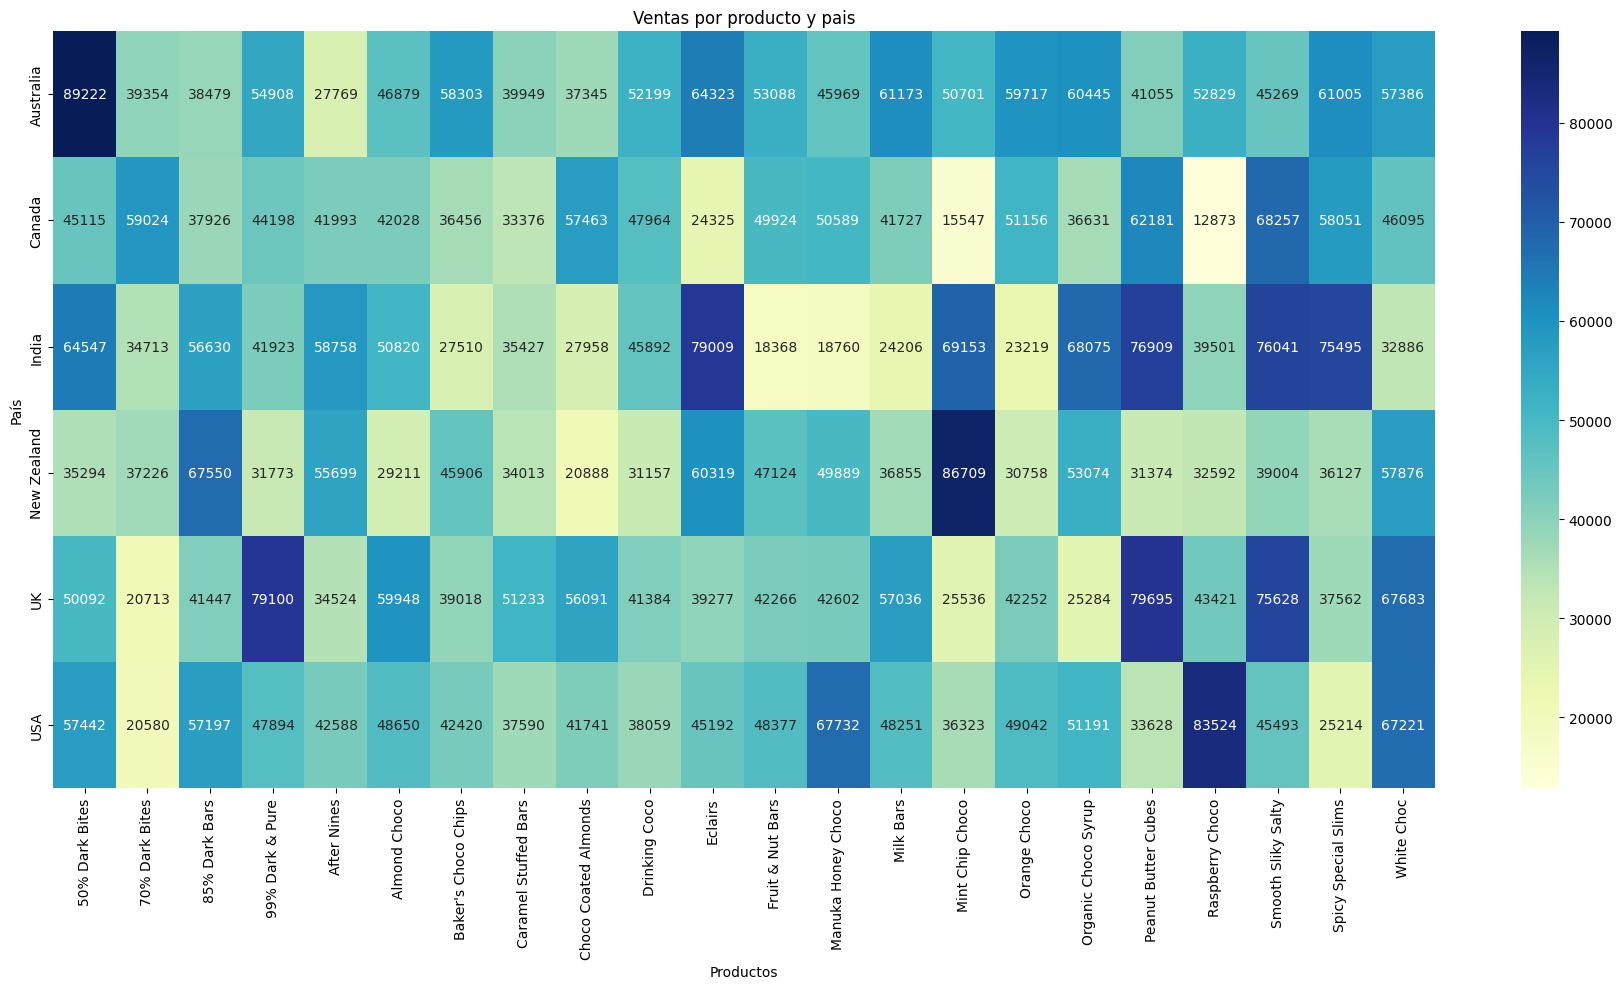

In [ ]:
#¿Qué producto generó más dinero en cada país?
import seaborn as sns
plt.figure(figsize=(18, 10))

sns.heatmap(producto_por_pais, annot=True, fmt=".0f", cmap="YlGnBu")

plt.title("Ventas por producto y pais")
plt.xlabel("Productos")
plt.ylabel("País")
plt.tight_layout()
plt.show()

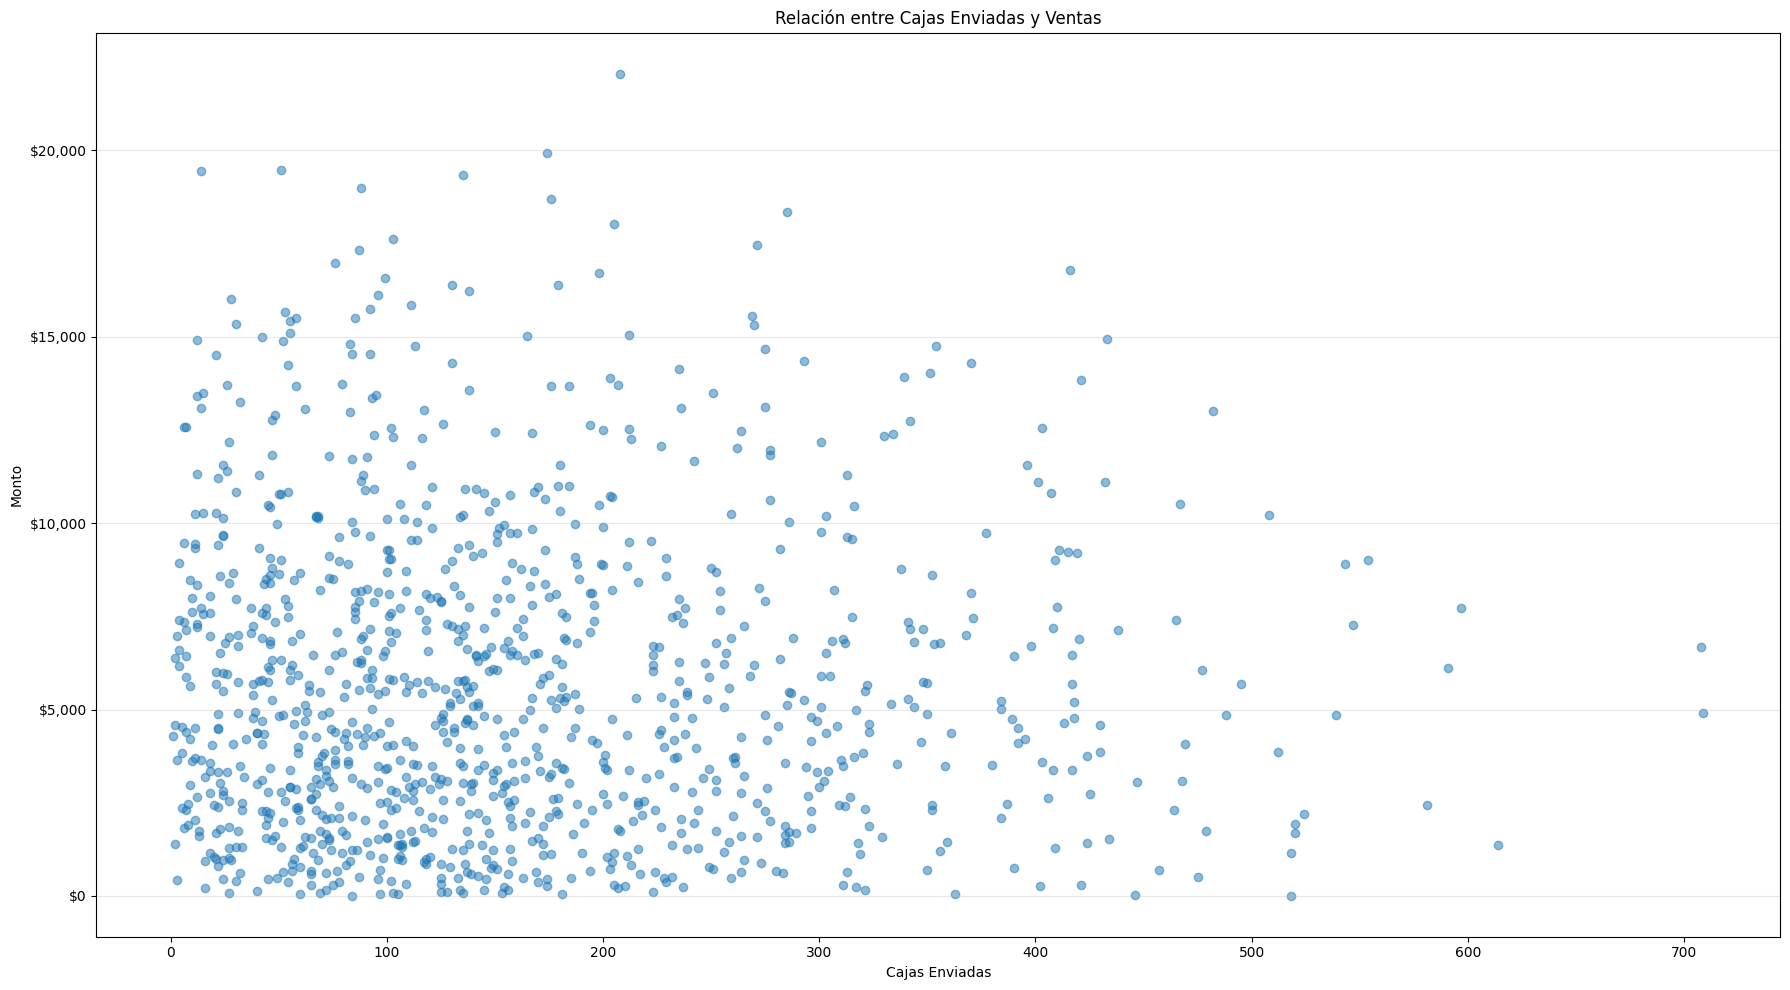

In [ ]:
# buscando valores atipicos en las ventas por producto y país
plt.figure(figsize=(18, 10))

plt.scatter(data["Cajas_enviadas"], data["Monto"], alpha=0.5)
plt.xlabel("Cajas Enviadas")
plt.ylabel("Monto")
plt.title("Relación entre Cajas Enviadas y Ventas")

# damos formato de dinero a los valores del eje y
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'${x:,.0f}'))
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()